In [4]:
import pandas as pd

df = pd.read_csv("sakshi_dataset.csv", sep=';')

In [5]:

print(df.columns.tolist())
print(df.head())

['seq', 'timestamp_ms', 'red', 'ir', 'red_corrected', 'ir_corrected']
   seq  timestamp_ms    red      ir  red_corrected  ir_corrected
0    1        135093  40603  100950     -10.788063     -4.396235
1    2        135113  40616  100938       2.142789    -15.105669
2    3        135133  40603  100945     -12.051503     -7.542110
3    4        135153  40612  100939      -0.769166    -14.245303
4    5        135173  40621  100933       8.087457    -20.552190


In [6]:
numeric_cols = [
    'seq',
    'timestamp_ms',
    'red',
    'ir',
    'red_corrected',
    'ir_corrected'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_%': round(df.isnull().mean()*100, 2)
})

print(missing_df)

               Missing_Count  Missing_%
seq                        0        0.0
timestamp_ms               0        0.0
red                        0        0.0
ir                         0        0.0
red_corrected              0        0.0
ir_corrected               0        0.0


In [8]:
strategy = []

for col in df.columns:
    pct = df[col].isnull().mean()*100

    if pct == 0:
        strategy.append("No Missing")
    elif pct < 5:
        strategy.append("Linear Interpolation")
    elif pct < 20:
        strategy.append("Forward Fill")
    else:
        strategy.append("Investigate/Drop")

missing_df["Recommended_Strategy"] = strategy

print(missing_df)

               Missing_Count  Missing_% Recommended_Strategy
seq                        0        0.0           No Missing
timestamp_ms               0        0.0           No Missing
red                        0        0.0           No Missing
ir                         0        0.0           No Missing
red_corrected              0        0.0           No Missing
ir_corrected               0        0.0           No Missing


In [9]:
df['time_gap'] = df['timestamp_ms'].diff()

print(df['time_gap'].describe())

count    7422.000000
mean       19.884937
std        13.002916
min      -216.000000
25%        16.000000
50%        20.000000
75%        22.000000
max       218.000000
Name: time_gap, dtype: float64


In [10]:
expected_gap = df['time_gap'].mode()[0]

discontinuities = df[
    df['time_gap'] != expected_gap
]

print("Discontinuities:")
print(discontinuities)

Discontinuities:
       seq  timestamp_ms    red      ir  red_corrected  ir_corrected  time_gap
0        1        135093  40603  100950     -10.788063     -4.396235       NaN
9       10        135276  40596  100902     -17.972481    -49.652009      23.0
12      13        135339  40575  100839     -37.745463   -111.475993      23.0
13      14        135349  40576  100847     -36.888740   -102.581987      10.0
15      16        135399  40558  100788     -51.303304   -160.500637      30.0
...    ...           ...    ...     ...            ...           ...       ...
7415  7366        282546  41028  100392     134.718889    271.683683      10.0
7419  7370        282631  41017  100368     125.961639    245.201632      25.0
7420  7371        282647  41019  100382     124.367131    254.621961      16.0
7421  7372        282663  41037  100422     143.490628    291.425022      16.0
7422  7373        282679  41056  100444     164.845292    309.981452      16.0

[5071 rows x 7 columns]


In [11]:
df['time_sec'] = df['timestamp_ms']/1000

df['red_ir_ratio'] = df['red'] / df['ir']

df['red_minus_ir'] = df['red'] - df['ir']

df['red_rolling_mean'] = df['red'].rolling(10).mean()

df['ir_rolling_mean'] = df['ir'].rolling(10).mean()

df['red_diff'] = df['red'].diff()

df['ir_diff'] = df['ir'].diff()

df['red_pct_change'] = df['red'].pct_change()

df['ir_pct_change'] = df['ir'].pct_change()

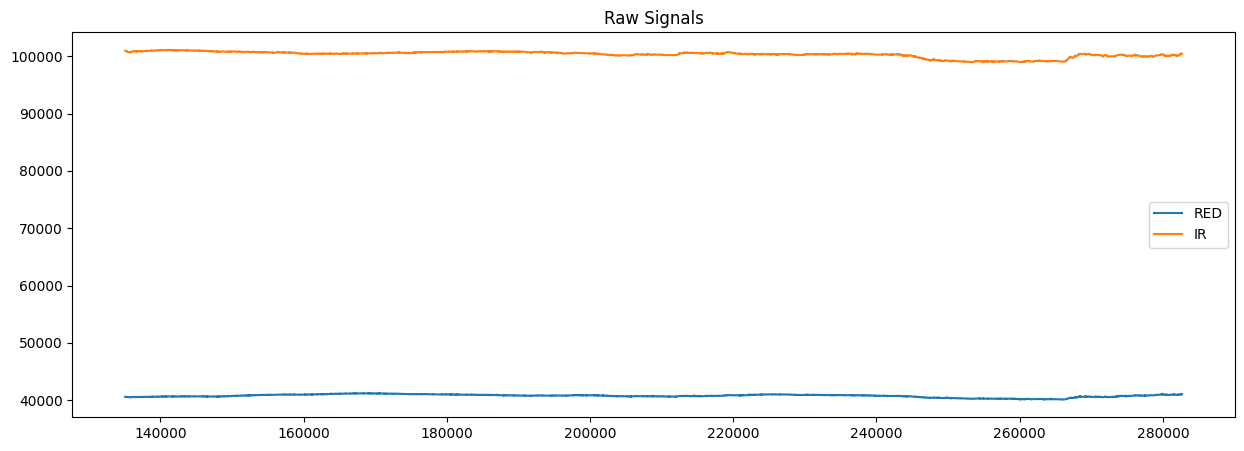

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['timestamp_ms'], df['red'], label='RED')
plt.plot(df['timestamp_ms'], df['ir'], label='IR')
plt.legend()
plt.title('Raw Signals')
plt.show()

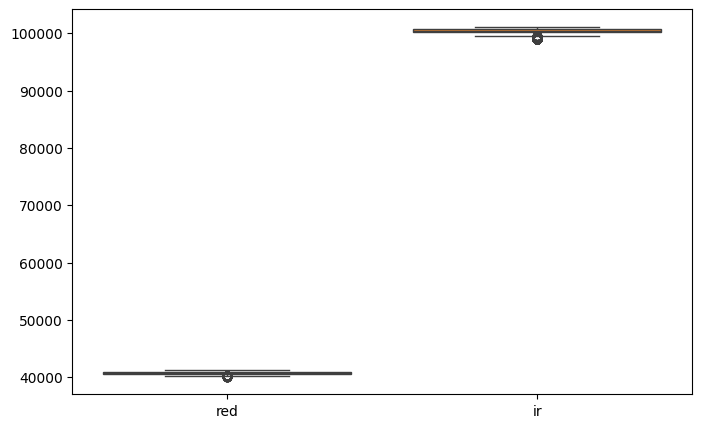

In [15]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df[['red','ir']])
plt.show()

In [16]:
def detect_outliers_iqr(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return ((series < lower) | (series > upper))

df['red_outlier'] = detect_outliers_iqr(df['red'])
df['ir_outlier'] = detect_outliers_iqr(df['ir'])

print("RED Outliers:", df['red_outlier'].sum())
print("IR Outliers:", df['ir_outlier'].sum())

RED Outliers: 276
IR Outliers: 993


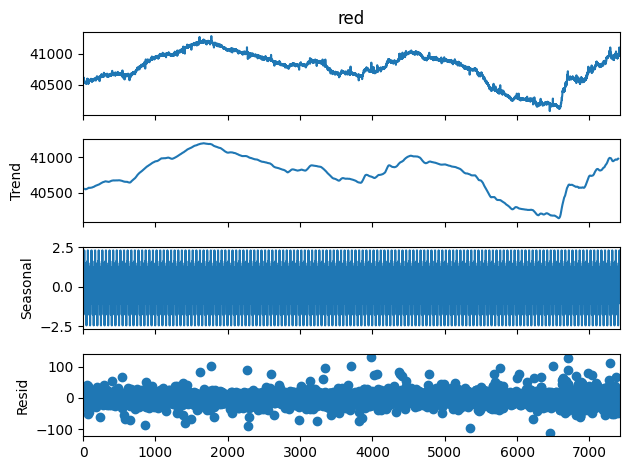

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = df['red']

result = seasonal_decompose(
    series,
    model='additive',
    period=50
)

result.plot()
plt.show()

In [20]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['red'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

ADF Statistic: -0.9789278464134196
p-value: 0.760872094056334
Non-Stationary


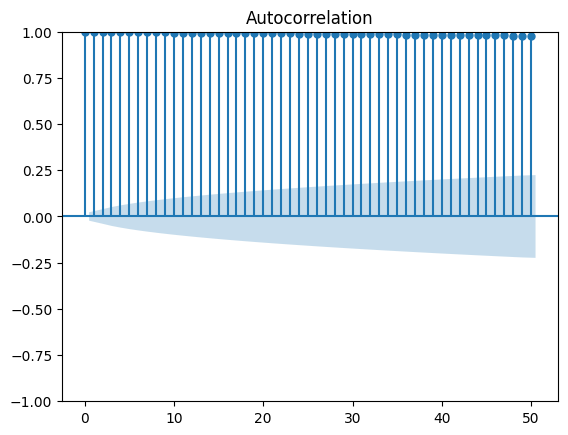

In [21]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    df['red'].dropna(),
    lags=50
)

plt.show()

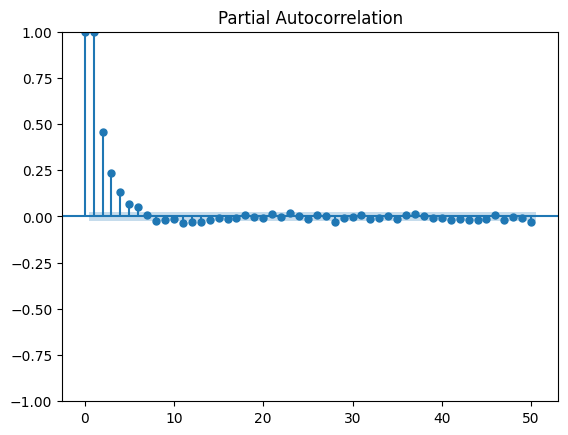

In [22]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(
    df['red'].dropna(),
    lags=50
)

plt.show()

In [23]:
eda_summary = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Missing Values": int(df.isnull().sum().sum()),
    "Red Outliers": int(df['red_outlier'].sum()),
    "IR Outliers": int(df['ir_outlier'].sum()),
    "Expected Sampling Gap(ms)": expected_gap
}

print(pd.DataFrame([eda_summary]))

   Rows  Columns  Missing Values  Red Outliers  IR Outliers  \
0  7423       18              23           276          993   

   Expected Sampling Gap(ms)  
0                       20.0  


In [24]:
import os

ARTIFACT_DIR = "Artifacts"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f"Artifacts will be saved in: {ARTIFACT_DIR}")

Artifacts will be saved in: Artifacts


In [25]:
feature_cols = [
    'time_sec',
    'red_ir_ratio',
    'red_minus_ir',
    'red_rolling_mean',
    'ir_rolling_mean',
    'red_diff',
    'ir_diff',
    'red_pct_change',
    'ir_pct_change'
]

pd.DataFrame({
    "Feature_Engineered_Columns": feature_cols
}).to_csv(
    f"{ARTIFACT_DIR}/feature_engineering_report.csv",
    index=False
)

In [26]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (
        df.isnull().mean()*100
    ).round(2).values
})

missing_df.to_csv(
    f"{ARTIFACT_DIR}/missing_value_report.csv",
    index=False
)

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['timestamp_ms'], df['red'], label='RED')
plt.plot(df['timestamp_ms'], df['ir'], label='IR')

plt.legend()
plt.title("Time Series Signals")

plt.savefig(
    f"{ARTIFACT_DIR}/time_series_plot.png",
    bbox_inches='tight'
)

plt.close()

In [28]:
plt.figure(figsize=(8,5))

df[['red','ir']].boxplot()

plt.title("Boxplot")

plt.savefig(
    f"{ARTIFACT_DIR}/boxplot.png",
    bbox_inches='tight'
)

plt.close()

In [29]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['red'].dropna())

stationary_df = pd.DataFrame({
    "ADF_Statistic":[adf_result[0]],
    "P_Value":[adf_result[1]],
    "Stationary":[adf_result[1] < 0.05]
})

stationary_df.to_csv(
    f"{ARTIFACT_DIR}/stationarity_report.csv",
    index=False
)

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['red'].dropna(),
    model='additive',
    period=50
)

fig = result.plot()

fig.savefig(
    f"{ARTIFACT_DIR}/decomposition_plot.png",
    bbox_inches='tight'
)

plt.close()

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10,5))

plot_acf(
    df['red'].dropna(),
    lags=50,
    ax=ax
)

plt.savefig(
    f"{ARTIFACT_DIR}/acf_plot.png",
    bbox_inches='tight'
)

plt.close()

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(10,5))

plot_pacf(
    df['red'].dropna(),
    lags=50,
    ax=ax
)

plt.savefig(
    f"{ARTIFACT_DIR}/pacf_plot.png",
    bbox_inches='tight'
)

plt.close()

In [33]:
summary = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Missing_Values": int(df.isnull().sum().sum())
}

pd.DataFrame([summary]).to_csv(
    f"{ARTIFACT_DIR}/eda_summary.csv",
    index=False
)

In [34]:
plt.figure(figsize=(15,5))

plt.plot(df['timestamp_ms'], df['red'], color='red', label='RED')
plt.plot(df['timestamp_ms'], df['ir'], color='blue', label='IR')

plt.legend()
plt.title("Time Series Signals")

plt.savefig(
    f"{ARTIFACT_DIR}/time_series_plot.png",
    bbox_inches='tight'
)

plt.close()